In [2]:
import pandas as pd
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
import os
print(os.getcwd())

messages = pd.read_csv('../data/SMSSpamCollection.txt',sep='\t',names=['label', 'message'])
messages.head()

c:\Users\ACER\Desktop\ML algos\spam-text-classification\notebooks


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
messages.shape

(5572, 2)

In [5]:
ps=PorterStemmer()

In [6]:
corpus =[]
for i in range(0,len(messages)):
    review = re.sub('[^a-zA-Z]',' ',messages['message'][i])# to remove the special characters
    review = review.lower() # to convert the text into lower case
    review = review.split() # to split the text into words
    review = [ps.stem(word) for word in review if  not word in stopwords.words('english')] # to remove the stop words and to apply stemming
    review = ' '. join(review)
    corpus.append(review)

In [7]:
corpus

['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
 'ok lar joke wif u oni',
 'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli',
 'u dun say earli hor u c alreadi say',
 'nah think goe usf live around though',
 'freemsg hey darl week word back like fun still tb ok xxx std chg send rcv',
 'even brother like speak treat like aid patent',
 'per request mell mell oru minnaminungint nurungu vettam set callertun caller press copi friend callertun',
 'winner valu network custom select receivea prize reward claim call claim code kl valid hour',
 'mobil month u r entitl updat latest colour mobil camera free call mobil updat co free',
 'gonna home soon want talk stuff anymor tonight k cri enough today',
 'six chanc win cash pound txt csh send cost p day day tsandc appli repli hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw',
 'search right word thank breather

In [8]:
y = pd.get_dummies(messages['label'])
y = y.iloc[:,0].values
y

array([ True,  True, False, ...,  True,  True,  True], shape=(5572,))

In [9]:
X_train,X_test,y_train,y_test = train_test_split(corpus,y,test_size = 0.20)
results = []

In [10]:
cv = CountVectorizer(max_features = 2500, ngram_range = (1,2))

In [11]:
len(X_train), len(y_train)

(4457, 4457)

In [12]:
X_train = cv.fit_transform(X_train).toarray()
X_test = cv.transform(X_test).toarray()

In [13]:
cv.vocabulary_

{'still': np.int64(1979),
 'work': np.int64(2421),
 'go': np.int64(811),
 'small': np.int64(1910),
 'hous': np.int64(973),
 'hi': np.int64(935),
 'tri': np.int64(2171),
 'call': np.int64(250),
 'unabl': np.int64(2218),
 'reach': np.int64(1682),
 'pl': np.int64(1572),
 'give': np.int64(803),
 'miss': np.int64(1316),
 'cal': np.int64(249),
 'msg': np.int64(1369),
 'pl give': np.int64(1576),
 'wnt': np.int64(2415),
 'buy': np.int64(240),
 'car': np.int64(293),
 'urgent': np.int64(2256),
 'vri': np.int64(2303),
 'hv': np.int64(989),
 'lt': np.int64(1220),
 'gt': np.int64(873),
 'lac': np.int64(1094),
 'sourc': np.int64(1942),
 'di': np.int64(531),
 'amt': np.int64(65),
 'that': np.int64(2097),
 'prob': np.int64(1649),
 'urgent vri': np.int64(2263),
 'urgent hv': np.int64(2258),
 'lt gt': np.int64(1222),
 'gt lac': np.int64(876),
 'amt lt': np.int64(66),
 'parent': np.int64(1526),
 'kidz': np.int64(1080),
 'friend': np.int64(749),
 'colleagu': np.int64(377),
 'scream': np.int64(1795),
 'sur

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [15]:
spam_detect_model = model.fit(X_train, y_train)
y_pred = spam_detect_model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

In [17]:
accuracy_score(y_test, y_pred)

0.9838565022421525

In [18]:
print(classification_report(y_test, y_pred))
results.append(['Counter Vectorization + Logistic Regression', accuracy_score(y_test, y_pred)])

              precision    recall  f1-score   support

       False       0.98      0.90      0.94       151
        True       0.98      1.00      0.99       964

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [19]:
#-----TF-IDF IMPLEMENTATION-----

In [20]:
from collections import Counter
print(Counter(y_train))

Counter({np.True_: 3861, np.False_: 596})


In [21]:
model = LogisticRegression(class_weight='balanced')

In [22]:
X_train,X_test,y_train,y_test = train_test_split(corpus,y,test_size = 0.20)

In [23]:
X_train = [' '.join(x) if isinstance(x, list) else str(x) for x in X_train]
X_test = [' '.join(x) if isinstance(x, list) else str(x) for x in X_test]

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer(max_features=2500, ngram_range=(1,2))

X_train = tv.fit_transform(X_train).toarray()
X_test = tv.transform(X_test).toarray()


In [25]:
tv.vocabulary_

{'ok': np.int64(1467),
 'theori': np.int64(2090),
 'test': np.int64(2067),
 'go': np.int64(787),
 'book': np.int64(204),
 'think': np.int64(2092),
 'may': np.int64(1263),
 'coz': np.int64(441),
 'thought': np.int64(2102),
 'wanna': np.int64(2320),
 'isnt': np.int64(1010),
 'free': np.int64(711),
 'happi': np.int64(882),
 'new': np.int64(1409),
 'year': np.int64(2475),
 'ur': np.int64(2233),
 'famili': np.int64(647),
 'bring': np.int64(221),
 'colour': np.int64(373),
 'life': np.int64(1127),
 'happi new': np.int64(885),
 'new year': np.int64(1415),
 'get': np.int64(763),
 'nigeria': np.int64(1422),
 'call': np.int64(244),
 'later': np.int64(1085),
 'afternoon': np.int64(32),
 'servic': np.int64(1833),
 'problem': np.int64(1640),
 'south': np.int64(1939),
 'hear': np.int64(891),
 'listen': np.int64(1144),
 'call later': np.int64(259),
 'appar': np.int64(83),
 'quick': np.int64(1652),
 'good': np.int64(811),
 'need': np.int64(1399),
 'receipt': np.int64(1687),
 'well': np.int64(2369),
 'd

In [26]:
tfidf_model_predictor = model.fit(X_train,y_train)
y_pred = tfidf_model_predictor.predict(X_test)

In [27]:
accuracy_score(y_test, y_pred)

0.97847533632287

In [28]:
print(classification_report(y_test, y_pred))
results.append(['TF-IDF + Logistic Regression', accuracy_score(y_test, y_pred)])

              precision    recall  f1-score   support

       False       0.91      0.93      0.92       152
        True       0.99      0.99      0.99       963

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [29]:
#------USING NAIVE BAYES CLASSIFIER------

In [30]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [31]:
accuracy_score(y_test, y_pred)

0.9748878923766816

In [32]:
print(classification_report(y_test, y_pred, zero_division=0))
results.append(['Naive Bayes', accuracy_score(y_test, y_pred)])

              precision    recall  f1-score   support

       False       0.99      0.82      0.90       152
        True       0.97      1.00      0.99       963

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



In [33]:
df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\n===== FINAL COMPARISON =====")
print(df_results.sort_values(by="Accuracy", ascending=False))


===== FINAL COMPARISON =====
                                         Model  Accuracy
0  Counter Vectorization + Logistic Regression  0.983857
1                 TF-IDF + Logistic Regression  0.978475
2                                  Naive Bayes  0.974888


In [34]:
results.append({
    "Model": model,
    "Accuracy": accuracy_score
})

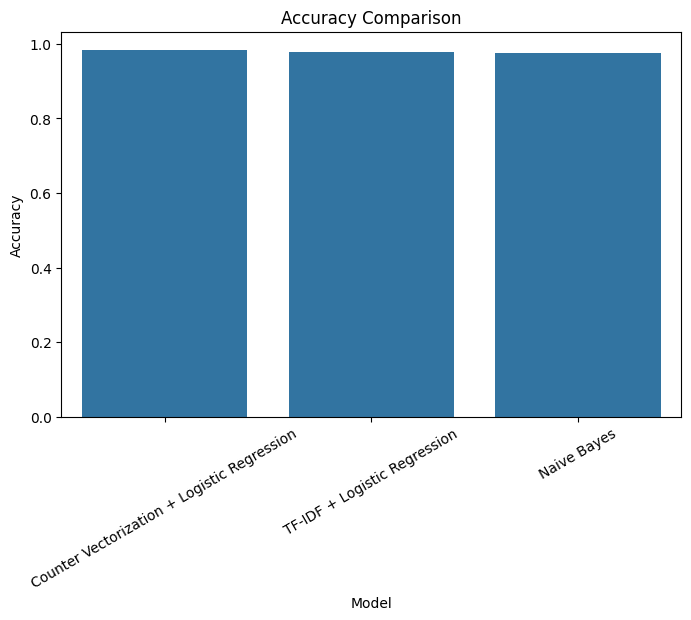

In [35]:
#-------ACCURACY COMPARISON (BAR PLOT)------

plt.figure(figsize=(8,5))
sns.barplot(data=df_results, x='Model', y='Accuracy')
plt.title("Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

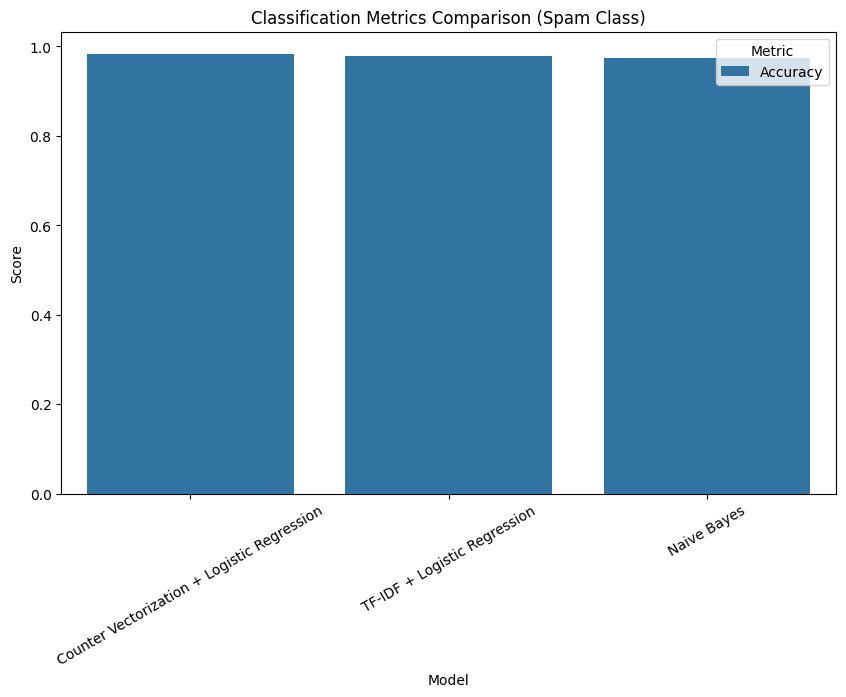

In [36]:
#------CLASSIFICATION REPORT------

report_melt = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=report_melt, x='Model', y='Score', hue='Metric')
plt.title("Classification Metrics Comparison (Spam Class)")
plt.xticks(rotation=30)
plt.show()

In [37]:
#------HEATMAP OF CLASSIFICATION REPORT------

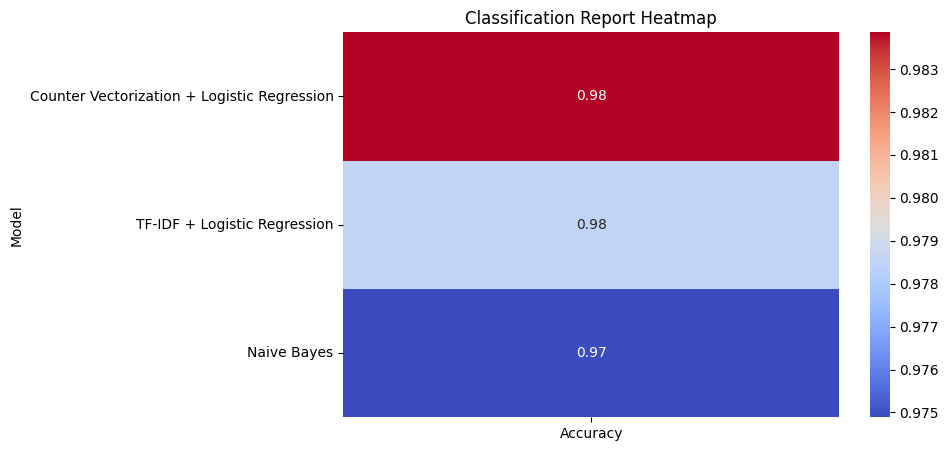

In [38]:
df_results.set_index("Model", inplace=True)

plt.figure(figsize=(8,5))
sns.heatmap(df_results, annot=True, cmap="coolwarm")
plt.title("Classification Report Heatmap")
plt.show()